In [12]:
from qick import *
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=mpl.colormaps['Set1'].colors
)

import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
# from tqdm import tqdm
from tqdm.notebook import tqdm
import xarray as xr

In [13]:
import os
import sys
sys.path.insert(0, '../../pattern/')
from helper_sweep import do_sweep

sys.path.insert(0, '../../instrument/')
from xilinx_qick.class_drx import drx
from xilinx_qick.class_rox import rox
from xilinx_qick.class_sweep import sweep
from xilinx_qick.instr_xilinx_v1 import XilinxProg

In [14]:
from pathlib import Path

folder_name = Path.cwd().name
data_dir = Path("Z:/labdata/qcdlabs") / folder_name
data_dir.mkdir(parents=True, exist_ok=True)

In [15]:
xilinx_1 = XilinxProg(ip_address="10.0.100.21", mode='AveragerProgram')
xilinx_1.reps = int(1)
dr_ch0 = 0
ro_ch0 = 0

ro_ch1 = 1

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
rfsoc4x2_1 PYRO:obj_d7bc762464ae4621a0e7e64d156de3af@10.0.100.21:41869
QICK running on RFSoC4x2, software version 0.2.381

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decima

In [16]:
def set_modulation(xilinx_1,
                   frequency_ch0_hz = None,
                   carrier_frequency_hz=None,
                   modulation_frequency_hz = None,
                   modulation_depth=None):

    if frequency_ch0_hz != None:
        xilinx_1.frequency_ch0_hz = frequency_ch0_hz
    else:
        frequency_ch0_hz = xilinx_1.frequency_ch0_hz

    if carrier_frequency_hz != None:
        xilinx_1.carrier_frequency_hz = carrier_frequency_hz
    else:
        carrier_frequency_hz = xilinx_1.carrier_frequency_hz

    if modulation_frequency_hz != None:
        xilinx_1.modulation_frequency_hz = modulation_frequency_hz
    else:
        modulation_frequency_hz = xilinx_1.modulation_frequency_hz

    if modulation_depth != None:
        xilinx_1.modulation_depth = modulation_depth
    else:
        modulation_depth = xilinx_1.modulation_depth

    dt = 1/614.4
    t_gen = np.arange(0, 3, dt)

    s_gen = 1 * np.exp(-1j*modulation_depth*np.sin(2*np.pi*modulation_frequency_hz/1e6*t_gen))
    s_gen = s_gen * np.exp(-1j*2*np.pi*(carrier_frequency_hz-frequency_ch0_hz)/1e6*t_gen)

    # from scipy.special import jv
    # s_gen = jv(0, modulation_depth)
    # s_gen += jv(1, modulation_depth) * np.exp(1j*2*np.pi*modulation_frequency_hz/1e6*t_gen)
    # s_gen += -jv(1, modulation_depth) * np.exp(-1j*2*np.pi*modulation_frequency_hz/1e6*t_gen)


    dr_readout1 = drx(soc=xilinx_1.soccfg,
                    dr_ch=dr_ch0, ro_ch=ro_ch0, frequency= frequency_ch0_hz / 1e6, gain=0.5, phase=0)

    dr_readout1.wave.add(name='x2', t_data=t_gen, s_data=s_gen, idx=-1, interp_order=1)
    dr_readout1.rox.set(length=1.8, delay=1, sleep=1)
    xilinx_1.add(dr_readout1=dr_readout1)

    ro_readout2 = rox(soc=xilinx_1.soccfg, ro_ch=ro_ch1, dr_ch=dr_ch0, frequency= frequency_ch0_hz / 1e6)
    ro_readout2.set(length=1.8, delay=1, sleep=1)
    xilinx_1.add(ro_readout2=ro_readout2)

xilinx_1.register_sweep(set_modulation,
                        frequency_ch0_hz = 8.1056e9,
                        carrier_frequency_hz = 8.1015e9,
                        modulation_frequency_hz = 1e6,
                        modulation_depth=0.5)

In [17]:
def set_reps(xilinx_1, reps=0):
    pass

xilinx_1.register_sweep(set_reps,
                        reps=1)

In [20]:
carrier_frequency_center = 8.1056e9
carrier_frequency_span = 40e6
carrier_frequency_step = 0.5e6

carrier_frequency_list = np.arange(carrier_frequency_center-carrier_frequency_span/2, carrier_frequency_center+carrier_frequency_span/2+1, carrier_frequency_step)

modulation_frequency_list = np.arange(0, 18e6+1, 3e6)
# modulation_frequency_list = np.array([2e6, 15e6])

reps_list = np.arange(0, 5, 1)

print(len(carrier_frequency_list), len(modulation_frequency_list), len(reps_list))

81 7 5


In [21]:
config_device = [xilinx_1]
config_sweep = [
    [
        [xilinx_1.sweep, 'carrier_frequency_hz', carrier_frequency_list],
    ],
    [
        [xilinx_1.sweep, 'modulation_frequency_hz', modulation_frequency_list],
    ],
    [
        [xilinx_1.sweep, 'reps', reps_list],
    ],
]

In [ ]:
_file_name = 'test_dds_modulation.zarr'
file_name= data_dir / _file_name

do_sweep(config_device, config_sweep, xilinx_1.acquire_decimated, file_name)

# xilinx_1.soc.reset_gens()

  5%|▌         | 142/2835 [01:49<34:26,  1.30it/s]

In [ ]:
# src = data_dir / "test_dds_modulation.zarr"
# dst = data_dir / "test_dds_modulation_onechunk.zarr"
#
# import zarr
# zarr.consolidate_metadata(str(src))
#
# ds = xr.open_zarr(src, consolidated=True, chunks={})
# chunk_plan = {dim: size for dim, size in ds.sizes.items()}
#
# ds_one = ds.chunk(chunk_plan)
# ds_one.to_zarr(
#     dst,
#     mode="w",
#     consolidated=True,
#     zarr_format=2
# )

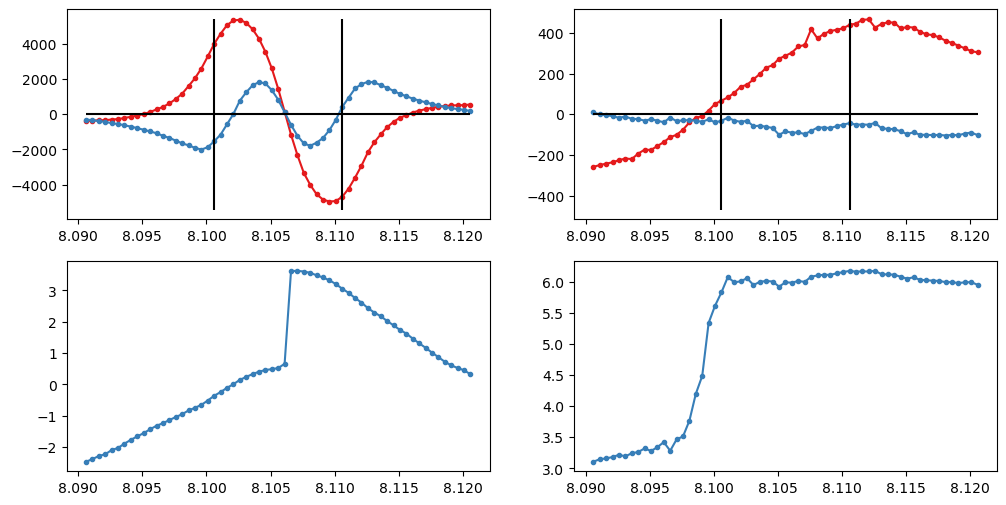

In [10]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name, consolidated=True) as f:
    iq_mat = f['IQ decimated'].load()

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

modulation_frequency_hz = 5e6

for _rox in iq_mat.rfsoc4x2_1_rox[::-1]:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    t_exp = s_data.tx

    # s_ref = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    #
    # s_data = s_data / (s_ref/np.abs(s_ref))

    # p_mean = (s_data * np.conj(s_data) ).mean(dim='rfsoc4x2_1_reps')

    s_mean = s_data.mean(dim='rfsoc4x2_1_reps')
    p_mean = s_mean * np.conj(s_mean)

    plot_carrier_frequency = p_mean.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    # s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    # s_pdh = s_demod * p_mean

    fs_dec = 552.960e6
    total_N = p_mean.sizes['rfsoc4x2_1_ticks']

    if modulation_frequency_hz == 0:
        idx = total_N
    else:
        n_cycles = int(total_N * modulation_frequency_hz / fs_dec)
        idx = int(round(n_cycles * fs_dec / modulation_frequency_hz))
        idx = min(idx, total_N)

    # idx = np.searchsorted(p_mean.tx.values, t_int, side='right')

    p_use = p_mean.isel(rfsoc4x2_1_ticks=slice(0, idx))
    # p_use = p_use - p_use.mean(dim='rfsoc4x2_1_ticks')
    t_use = p_mean.tx

    s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_use)
    s_int = (s_demod * p_use).mean(dim='rfsoc4x2_1_ticks')

    # if _rox == 1:
    #     s_ref = s_int.copy()
    # else:
    #     s_int = s_int * np.exp(-1j*np.angle(s_ref))

    # s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    # s_demod[idx:] = 0
    # s_int = (s_demod * p_mean).mean(dim='rfsoc4x2_1_ticks')

    # s_int = s_pdh.isel(rfsoc4x2_1_ticks=slice(0, idx)).mean(dim='rfsoc4x2_1_ticks')
    # s_int = s_pdh.isel(rfsoc4x2_1_ticks=slice(0, idx)).integrate('tx')

    # s_int = s_pdh.where(s_pdh.tx <= t_int, drop=True).integrate('tx')

    re_pdh = np.real(s_int)
    im_pdh = np.imag(s_int)

    ax0.plot(plot_carrier_frequency, re_pdh, '.-', color='C0')
    ax0.plot(plot_carrier_frequency, im_pdh, '.-', color='C1')

    am_pdh = np.abs(s_int)
    ph_pdh = np.unwrap(np.angle(s_int))

    # ax1.plot(plot_carrier_frequency, am_pdh, '.-', color='C0')
    ax1.plot(plot_carrier_frequency, ph_pdh, '.-', color='C1')

    # ax1.scatter(re_pdh, im_pdh, c=plot_carrier_frequency, cmap='RdBu_r')

    ax0.hlines(0, plot_carrier_frequency[0], plot_carrier_frequency[-1], color='k')

    ax0.vlines((8.1056e9-modulation_frequency_hz)/1e9, -np.max(np.abs(s_int)), np.max(np.abs(s_int)), color='k')
    ax0.vlines((8.1056e9+modulation_frequency_hz)/1e9, -np.max(np.abs(s_int)), np.max(np.abs(s_int)), color='k')

plt.show()

In [ ]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated']

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

modulation_frequency_hz = 5e6

for _rox in iq_mat.rfsoc4x2_1_rox[:]:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    t_exp = s_data.tx

    p_mean = (s_data * np.conj(s_data) ).mean(dim='rfsoc4x2_1_reps')

    # s_mean = s_data.mean(dim='rfsoc4x2_1_reps')
    # p_mean = s_mean * np.conj(s_mean)

    plot_carrier_frequency = p_mean.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    # s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    # s_pdh = s_demod * p_mean

    if modulation_frequency_hz == 0:
        t_int = p_mean.tx[-1]
    else:
        T_mod = 1e6/modulation_frequency_hz
        N_period = int(p_mean.tx[-1] // T_mod)
        t_int = N_period * T_mod

    idx = np.searchsorted(p_mean.tx.values, t_int, side='right')

    s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    s_demod[idx:] = 0
    s_int = (s_demod * p_mean).mean(dim='rfsoc4x2_1_ticks')

    re_pdh = np.real(s_int)
    im_pdh = np.imag(s_int)

    # ax0.plot(plot_carrier_frequency, re_pdh, '-', color='C0')
    # ax0.plot(plot_carrier_frequency, im_pdh, '-', color='C1')

    from scipy.signal import savgol_filter, find_peaks
    dphase = (re_pdh/im_pdh).data.compute()

    dphase2 = np.gradient(dphase, plot_carrier_frequency)
    peaks_phase, props = find_peaks(dphase2,
                                    distance=3)

    # peaks_phase = np.where(np.abs(dphase2) > 2000)[0]

    all_idx = np.arange(len(plot_carrier_frequency))
    rest_idx = np.setdiff1d(all_idx, peaks_phase)

    ax0.plot(plot_carrier_frequency[peaks_phase], re_pdh[peaks_phase], '.-', color='k', alpha=0.3)
    # ax0.plot(plot_carrier_frequency[peaks_phase], im_pdh[peaks_phase], '.-', color='k', alpha=0.3)

    ax0.plot(plot_carrier_frequency[rest_idx], re_pdh[rest_idx], '.-', color='C0', alpha=0.3)
    # ax0.plot(plot_carrier_frequency[rest_idx], im_pdh[rest_idx], '.-', color='C1', alpha=0.3)

    ax1.plot(plot_carrier_frequency, dphase2, '.-', color='C0', alpha=0.3)
    ax1.set_ylim(-1000,1000)

    # ax1.scatter(re_pdh[peaks_phase], im_pdh[peaks_phase], color='k', alpha=0.3)
    # ax1.scatter(re_pdh[rest_idx], im_pdh[rest_idx], color='C0', alpha=0.3)

plt.show()